### load

In [1]:
import numpy as np
import pandas as pd
import polars as pl
from polars import selectors as cs
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.linear_model import Ridge
from lightgbm import LGBMRegressor
from sklearn.preprocessing import StandardScaler, FunctionTransformer, OrdinalEncoder, OneHotEncoder, TargetEncoder, Binarizer
from sklearn.compose import ColumnTransformer, TransformedTargetRegressor
from sklearn.model_selection import train_test_split,cross_validate,KFold,GridSearchCV
from sklearn.metrics import root_mean_squared_log_error
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer, MissingIndicator
from sklearn.feature_selection import SelectFromModel
from sklearn.utils.validation import check_is_fitted
from category_encoders import CountEncoder

%matplotlib inline

from add_features import add_modified_features

In [2]:
train = pl.read_csv('../data/train.csv',infer_schema_length=None,null_values='NA')
test = pl.read_csv('../data/test.csv',infer_schema_length=None,null_values = 'NA')

print(train.shape, test.shape)

(1460, 81) (1459, 80)


In [3]:
# filter outlier
outlier_ids = [524, 1299]  # 確認した外れ値のId
train = train.filter(~pl.col('Id').is_in(outlier_ids))

X = train.select(cs.exclude('SalePrice'))
y = train['SalePrice']

X_test = test.select(cs.exclude('SalePrice'))
X.glimpse()

Rows: 1458
Columns: 80
$ Id            <i64> 1, 2, 3, 4, 5, 6, 7, 8, 9, 10
$ MSSubClass    <i64> 60, 20, 60, 70, 60, 50, 20, 60, 50, 190
$ MSZoning      <str> 'RL', 'RL', 'RL', 'RL', 'RL', 'RL', 'RL', 'RL', 'RM', 'RL'
$ LotFrontage   <i64> 65, 80, 68, 60, 84, 85, 75, null, 51, 50
$ LotArea       <i64> 8450, 9600, 11250, 9550, 14260, 14115, 10084, 10382, 6120, 7420
$ Street        <str> 'Pave', 'Pave', 'Pave', 'Pave', 'Pave', 'Pave', 'Pave', 'Pave', 'Pave', 'Pave'
$ Alley         <str> null, null, null, null, null, null, null, null, null, null
$ LotShape      <str> 'Reg', 'Reg', 'IR1', 'IR1', 'IR1', 'IR1', 'Reg', 'IR1', 'Reg', 'Reg'
$ LandContour   <str> 'Lvl', 'Lvl', 'Lvl', 'Lvl', 'Lvl', 'Lvl', 'Lvl', 'Lvl', 'Lvl', 'Lvl'
$ Utilities     <str> 'AllPub', 'AllPub', 'AllPub', 'AllPub', 'AllPub', 'AllPub', 'AllPub', 'AllPub', 'AllPub', 'AllPub'
$ LotConfig     <str> 'Inside', 'FR2', 'Inside', 'Corner', 'FR2', 'Inside', 'Inside', 'Corner', 'Inside', 'Corner'
$ LandSlope     <str> 'Gtl', 'Gtl

### explore

In [4]:
train.describe()

statistic,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,LotConfig,LandSlope,Neighborhood,Condition1,Condition2,BldgType,HouseStyle,OverallQual,OverallCond,YearBuilt,YearRemodAdd,RoofStyle,RoofMatl,Exterior1st,Exterior2nd,MasVnrType,MasVnrArea,ExterQual,ExterCond,Foundation,BsmtQual,BsmtCond,BsmtExposure,BsmtFinType1,BsmtFinSF1,BsmtFinType2,…,2ndFlrSF,LowQualFinSF,GrLivArea,BsmtFullBath,BsmtHalfBath,FullBath,HalfBath,BedroomAbvGr,KitchenAbvGr,KitchenQual,TotRmsAbvGrd,Functional,Fireplaces,FireplaceQu,GarageType,GarageYrBlt,GarageFinish,GarageCars,GarageArea,GarageQual,GarageCond,PavedDrive,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
str,f64,f64,str,f64,f64,str,str,str,str,str,str,str,str,str,str,str,str,f64,f64,f64,f64,str,str,str,str,str,f64,str,str,str,str,str,str,str,f64,str,…,f64,f64,f64,f64,f64,f64,f64,f64,f64,str,f64,str,f64,str,str,f64,str,f64,f64,str,str,str,f64,f64,f64,f64,f64,f64,str,str,str,f64,f64,f64,str,str,f64
"""count""",1458.0,1458.0,"""1458""",1199.0,1458.0,"""1458""","""91""","""1458""","""1458""","""1458""","""1458""","""1458""","""1458""","""1458""","""1458""","""1458""","""1458""",1458.0,1458.0,1458.0,1458.0,"""1458""","""1458""","""1458""","""1458""","""1450""",1450.0,"""1458""","""1458""","""1458""","""1421""","""1421""","""1420""","""1421""",1458.0,"""1420""",…,1458.0,1458.0,1458.0,1458.0,1458.0,1458.0,1458.0,1458.0,1458.0,"""1458""",1458.0,"""1458""",1458.0,"""768""","""1377""",1377.0,"""1377""",1458.0,1458.0,"""1377""","""1377""","""1458""",1458.0,1458.0,1458.0,1458.0,1458.0,1458.0,"""6""","""281""","""54""",1458.0,1458.0,1458.0,"""1458""","""1458""",1458.0
"""null_count""",0.0,0.0,"""0""",259.0,0.0,"""0""","""1367""","""0""","""0""","""0""","""0""","""0""","""0""","""0""","""0""","""0""","""0""",0.0,0.0,0.0,0.0,"""0""","""0""","""0""","""0""","""8""",8.0,"""0""","""0""","""0""","""37""","""37""","""38""","""37""",0.0,"""38""",…,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,"""0""",0.0,"""0""",0.0,"""690""","""81""",81.0,"""81""",0.0,0.0,"""81""","""81""","""0""",0.0,0.0,0.0,0.0,0.0,0.0,"""1452""","""1177""","""1404""",0.0,0.0,0.0,"""0""","""0""",0.0
"""mean""",730.251715,56.893004,null,69.797331,10459.9369,null,null,null,null,null,null,null,null,null,null,null,null,6.093964,5.576132,1971.218107,1984.834019,null,null,null,null,null,102.753793,null,null,null,null,null,null,null,438.82716,null,…,345.762003,5.852538,1510.465706,0.423868,0.057613,1.563786,0.38203,2.866255,1.046639,null,6.510974,null,0.611111,null,null,1978.464052,null,1.766118,472.050069,null,null,null,94.084362,46.245542,21.984225,3.414266,15.081619,2.433471,null,null,null,43.548697,6.323045,2007.816187,null,null,180932.919067
"""std""",421.601532,42.329437,null,23.203458,9859.198156,null,null,null,null,null,null,null,null,null,null,null,null,1.376369,1.113359,30.193754,20.64176,null,null,null,null,null,179.442156,null,null,null,null,null,null,null,432.969094,null,…,435.423924,48.65596,507.878508,0.517404,0.238907,0.549891,0.50271,0.816323,0.220483,null,1.61588,null,0.641988,null,null,24.682879,null,0.747104,212.239248,null,null,null,125.350021,65.312932,61.155666,29.337173,55.792877,38.209947,null,null,null,496.460799,2.700167,1.328826,null,null,79495.055285
"""min""",1.0,20.0,"""C (all)""",21.0,1300.0,"""Grvl""","""Grvl""","""IR1""","""Bnk""","""AllPub""","""Corner""","""Gtl""","""Blmngtn""","""Artery""","""Artery""","""1Fam""","""1.5Fin""",1.0,1.0,1872.0,1950.0,"""Flat""","""CompShg""","""AsbShng""","""AsbShng""","""BrkCmn""",0.0,"""Ex""","""Ex""","""BrkTil""","""Ex""","""Fa""","""Av""","""ALQ""",0.0,"""ALQ""",…,0.0,0.0,334.0,0.0,0.0,0.0,0.0,0.0,0.0,"""Ex""",2.0,"""Maj1""",0.0,"""Ex""","""2Types""",1900.0,"""Fin""",0.0,0.0,"""Ex""","""Ex""","""N""",0.0,0.0,0.0,0.0,0.0,0.0,"""Ex""","""GdPrv""","""Gar2""",0.0,1.0,2006.0,"""COD""","""Abnorml""",34900.0
"""25%""",365.0,20.0,null,59.0,7540.0,null,null,null,

In [5]:
nulls = train.select(cs.numeric()).to_pandas().isna().sum()
nulls[nulls > 0]

LotFrontage    259
MasVnrArea       8
GarageYrBlt     81
dtype: int64

### col-prep mapping

In [6]:
map_label = {
    'Condition1':{
        'Artery':-1,
        'Feedr':-1,
        'Norm':0,
        'RRNn':-1,
        'RRAn':-1,
        'PosN':1,
        'PosA':1,
        'RRNe':-1,
        'RRAe':-1,
        },
    'Condition2':{
        'Artery':-1,
        'Feedr':-1,
        'Norm':0,
        'RRNn':-1,
        'RRAn':-1,
        'PosN':1,
        'PosA':1,
        'RRNe':-1,
        'RRAe':-1,
        },

    # 'NewFeat':{
    #     '':'',
    # },
    
}

eq_values_label = {
    'Street':['Pave'],
    'CentralAir': ['Y'],
    'Heating': ['GasA'],
    'PavedDrive': ['Y'],
    'RoofMatl': ['CompShg'],
    'Condition2':['PosN'],
    'SaleCondition':['Normal'],
    'LandContour':['Lvl'],
    'SaleType':['New'],
    'Foundation':['BrkTil','CBlock','PConc'],
    'Utilities': ['AllPub'],
    'GarageType': ['Attchd','BuiltIn']
}

is_na_label = [
    'Alley',
    'PoolQC',
    'Fence',
    'MiscFeature',
]

is_zero_label = [
    'LowQualFinSF',
    'PoolArea',
    'BsmtHalfBath',
    'ScreenPorch',
    '3SsnPorch',
    'MiscVal',
]


# 欠損 = データ不備（最頻値で補完）
ordinal_encoded_data_error = {
    'KitchenQual':['Po','Fa','TA','Gd','Ex'],
    'Functional':['Typ','Min1', 'Min2', 'Mod', 'Maj1', 'Maj2', 'Sev', 'Sal'],
    'ExterQual': ['Po','Fa','TA','Gd','Ex'],
    'ExterCond': ['Po','Fa','TA','Gd','Ex'],
}

# 欠損 = 該当設備なし（"Missing"で補完）
ordinal_encoded_no_feature = {
    'FireplaceQu':['Missing', 'Po','Fa','TA','Gd','Ex'],
    'GarageQual':['Missing', 'Po','Fa','TA','Gd','Ex'],
    'GarageCond': ['Missing', 'Po','Fa','TA','Gd','Ex'],
    'LotShape':['Reg','IR1','IR2','IR3'],
    'BsmtCond':['Missing','Po','Fa','TA','Gd','Ex'],
    'BsmtQual':['Missing','Po','Fa','TA','Gd','Ex'],
    'BsmtExposure':['Missing','No','Mn','Av','Gd'],    
}

one_hot_encoded = [  # 最頻値で補完
    'LotConfig',
    'LandSlope',
    'BldgType',
    'HouseStyle',
    'RoofStyle',
    'HeatingQC',
    'Electrical',
    'MasVnrType',
    'BsmtFinType1',
    'BsmtFinType2',
    'GarageFinish',
]

target_encoded = [
    'MSSubClass',
    'Neighborhood',
    'MSZoning',
    'TargetExterior1_2',
]

count_encoded = [  # 最頻値で補完
]

log_standardized = [ # 中央値で補完
    'LotFrontage',
    'LotArea',
    'BsmtUnfSF',
    'TotalBsmtSF',
    'BsmtFinSF1',
    'BsmtFinSF2',
    'MasVnrArea',
    'EnclosedPorch',
    'HalfBath',
    'OpenPorchSF',
    'WoodDeckSF',
    # 追加
    'TotalFlrSF',
    'BsmtAboveRatio',
    'LivLotRatio',
    'LivArea_x_Qual',
]

standardized = [ # 中央値で補完
    'OverallQual',
    'OverallCond',
    'BsmtFullBath',
    'FullBath',
    'BedroomAbvGr',
    'KitchenAbvGr',
    'TotRmsAbvGrd',
    'Fireplaces',
    'GarageYrBlt',
    'GarageCars',
    'GarageArea',
    'MoSold',
    'YrSold',
    'YearBuilt',
    'OverallScore',
    'BathScore',
    'BuildingAgeAtSale',
    'IsOverAllGE9',
    'SoldAfterRehman',
    'SoldMay2June',
    'AreaPerRooms',
    ]


### pipeline

In [7]:
# ---------Target-Pipeline----------- #

log_standardize_y = Pipeline([
    ("log", FunctionTransformer(np.log1p, inverse_func=np.expm1, check_inverse=False)),
    ("scale", StandardScaler())
])

# ---------Features-Pipeline----------- #

log_standardize = Pipeline([
    ("log", FunctionTransformer(np.log1p, inverse_func=np.expm1, check_inverse=False, feature_names_out="one-to-one")),
    ("scale", StandardScaler())
])

# map_label: 明示的な値->コードのマッピング（Street, CentralAir）
map_label_pipeline = Pipeline([
    ("ordinal", OrdinalEncoder(categories=[
        sorted(mapping, key=mapping.get) for mapping in map_label.values()
    ])),
    ("scale", StandardScaler()),
])

# eq_values_label: 指定値のいずれかと一致するかどうかの2値化（isinロジック）（Heating, PavedDrive）
def _eq_values_transform(X, mapping=eq_values_label):
    X = np.asarray(X)
    out = np.empty(X.shape, dtype=int)
    for i, values in enumerate(mapping.values()):
        out[:, i] = np.isin(X[:, i], values).astype(int)
    return out

eq_values_label_pipeline = Pipeline([
    ("eq", FunctionTransformer(
        _eq_values_transform,
        feature_names_out="one-to-one",
    )),
    ("scale", StandardScaler()),
])

# is_na_label: 欠損（＝その設備なし）を示す2値フラグ
is_na_label_pipeline = Pipeline([
    ("indicator", MissingIndicator(features="all", missing_values=None)),
    ("scale", StandardScaler()),
])

# is_zero_label: 0でないかを示す2値フラグ
is_zero_label_pipeline = Pipeline([
    ("impute", SimpleImputer(strategy="constant", fill_value=0)),
    ("binarize", Binarizer(threshold=0)),
    ("scale", StandardScaler()),
])

# ordinal_encoded_data_error: 欠損はデータ不備のため最頻値で補完してから順序エンコード
# ※ Functionalのみ Typ=0 を基準に悪化するほど負の値になるよう符号を反転する
ordinal_data_error_sign = np.array([-1 if col == 'Functional' else 1 for col in ordinal_encoded_data_error])

ordinal_encoded_data_error_pipeline = Pipeline([
    ("impute", SimpleImputer(strategy="most_frequent", missing_values=None)),
    ("ordinal", OrdinalEncoder(categories=list(ordinal_encoded_data_error.values()))),
    ("sign", FunctionTransformer(
        lambda X: np.asarray(X) * ordinal_data_error_sign,
        feature_names_out="one-to-one",
    )),
])

# ordinal_encoded_no_feature: 欠損は該当設備なしを意味するので"Missing"で補完してから順序エンコード
ordinal_encoded_no_feature_pipeline = Pipeline([
    ("impute", SimpleImputer(strategy="constant", fill_value="Missing", missing_values=None)),
    ("ordinal", OrdinalEncoder(categories=list(ordinal_encoded_no_feature.values()))),
])

# one_hot_encoded: 最頻値で補完してからOne-Hotエンコード
one_hot_encoded_pipeline = Pipeline([
    ("impute", SimpleImputer(strategy="most_frequent", missing_values=None)),
    ("onehot", OneHotEncoder(handle_unknown="ignore",min_frequency=0.01)),
])

# target_encoded: 最頻値で補完してからターゲットエンコード
target_encoded_pipeline = Pipeline([
    ("impute", SimpleImputer(strategy="most_frequent", missing_values=None)),
    ("target", TargetEncoder()),
    ("scale", StandardScaler())
])

# count_encoded: 最頻値で補完してからカウントエンコード
count_encoded_pipeline = Pipeline([
    ("impute", SimpleImputer(strategy="most_frequent", missing_values=None)),
    ("count", CountEncoder()),
])

# log_standardized: 中央値で補完してから対数変換+標準化
log_standardized_pipeline = Pipeline([
    ("impute", SimpleImputer(strategy="median")),
    ("log_standard", log_standardize),
])

# standardized: 中央値で補完してから標準化
standardized_pipeline = Pipeline([
    ("impute", SimpleImputer(strategy="median")),
    ("scale", StandardScaler()),
])

In [8]:
preprocessor = ColumnTransformer([
    ("map_label", map_label_pipeline, list(map_label.keys())),
    ("eq_val_label", eq_values_label_pipeline, list(eq_values_label.keys())),
    ("is_na_label", is_na_label_pipeline, is_na_label),
    ("is_zero_label", is_zero_label_pipeline, is_zero_label),
    ("ordinal_encoded_data_error", ordinal_encoded_data_error_pipeline, list(ordinal_encoded_data_error)),
    ("ordinal_encoded_no_feature", ordinal_encoded_no_feature_pipeline, list(ordinal_encoded_no_feature)),
    ("one_hot_encoded", one_hot_encoded_pipeline, one_hot_encoded),
    ("target_encoded", target_encoded_pipeline, target_encoded),
    ("count_encoded", count_encoded_pipeline, count_encoded),
    ("log_standardized", log_standardized_pipeline, log_standardized),
    ("standardized", standardized_pipeline, standardized),
], remainder="drop")


### add modified -> drop useless -> filter outlier ->train test split

In [9]:
# add modified
X = add_modified_features(X)
X_test = add_modified_features(X_test)

# drop useless
drop_feats = [
    'Id',
    '2ndFlrSF',
    '1stFlrSF',
    'GrLivArea',
    'Exterior1st',
    'Exterior2nd',
]
X = X.select(cs.exclude(drop_feats))
X_test = X_test.select(cs.exclude(drop_feats))

# split
X_train, X_va, y_train, y_va = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [10]:
X_train.head()

MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,LotConfig,LandSlope,Neighborhood,Condition1,Condition2,BldgType,HouseStyle,OverallQual,OverallCond,YearBuilt,YearRemodAdd,RoofStyle,RoofMatl,MasVnrType,MasVnrArea,ExterQual,ExterCond,Foundation,BsmtQual,BsmtCond,BsmtExposure,BsmtFinType1,BsmtFinSF1,BsmtFinType2,BsmtFinSF2,BsmtUnfSF,TotalBsmtSF,Heating,…,Fireplaces,FireplaceQu,GarageType,GarageYrBlt,GarageFinish,GarageCars,GarageArea,GarageQual,GarageCond,PavedDrive,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,OverallScore,BathScore,TotalFlrSF,IsOverAllGE9,BuildingAgeAtSale,BsmtAboveRatio,LivLotRatio,SoldMay2June,SoldAfterRehman,AreaPerRooms,HasGarage,TargetExterior1_2,LivArea_x_Qual
i64,str,i64,i64,str,str,str,str,str,str,str,str,str,str,str,str,i64,i64,i64,i64,str,str,str,i64,str,str,str,str,str,str,str,i64,str,i64,i64,i64,str,…,i64,str,str,i64,str,i64,i64,str,str,str,i64,i64,i64,i64,i64,i64,str,str,str,i64,i64,i64,str,str,i64,f64,i64,i8,i64,f64,f64,i8,i8,f64,i32,str,i64
20,"""RL""",70,8400,"""Pave""",null,"""Reg""","""Lvl""","""AllPub""","""Inside""","""Gtl""","""NAmes""","""Norm""","""Norm""","""1Fam""","""1Story""",5,6,1957,1957,"""Gable""","""CompShg""","""None""",0,"""TA""","""Gd""","""CBlock""","""TA""","""TA""","""No""","""Rec""",922,"""Unf""",0,392,1314,"""GasA""",…,0,null,"""Attchd""",1957,"""RFn""",1,294,"""TA""","""TA""","""Y""",250,0,0,0,0,0,null,null,null,0,6,2010,"""WD""","""Normal""",11,3.0,2628,0,53,1.0,0.156429,1,0,262.8,1,"""MetalSd_MetalSd""",6570
60,"""RL""",59,7837,"""Pave""",null,"""IR1""","""Lvl""","""AllPub""","""Inside""","""Gtl""","""Gilbert""","""Norm""","""Norm""","""1Fam""","""2Story""",6,7,1993,1994,"""Gable""","""CompShg""","""None""",0,"""Gd""","""TA""","""PConc""","""Gd""","""TA""","""No""","""Unf""",0,"""Unf""",0,799,799,"""GasA""",…,1,"""TA""","""Attchd""",1993,"""RFn""",2,380,"""TA""","""TA""","""Y""",0,40,0,0,0,0,null,null,null,0,5,2009,"""WD""","""Normal""",13,2.5,2370,0,15,0.508593,0.200459,1,1,224.428571,1,"""VinylSd_VinylSd""",9426
20,"""RL""",null,8750,"""Pave""",null,"""IR1""","""Lvl""","""AllPub""","""Inside""","""Gtl""","""NAmes""","""Norm""","""Norm""","""1Fam""","""1Story""",5,6,1970,1970,"""Gable""","""CompShg""","""BrkFace""",76,"""TA""","""TA""","""CBlock""","""TA""","""TA""","""No""","""BLQ""",828,"""Unf""",0,174,1002,"""GasA""",…,0,null,"""Detchd""",1973,"""Unf""",2,902,"""TA""","""TA""","""Y""",0,0,0,0,0,0,null,"""MnPrv""",null,0,8,2009,"""WD""","""Normal""",11,3.0,2004,0,39,1.0,0.114514,0,1,200.4,1,"""MetalSd_MetalSd""",5010
50,"""RL""",60,7200,"""Pave""",null,"""Reg""","""Lvl""","""AllPub""","""Corner""","""Gtl""","""SWISU""","""Feedr""","""Norm""","""1Fam""","""1.5Fin""",5,7,1937,1950,"""Gable""","""CompShg""","""BrkFace""",252,"""TA""","""TA""","""BrkTil""","""Gd""","""TA""","""No""","""ALQ""",569,"""Unf""",0,162,731,"""GasA""",…,2,"""TA""","""Detchd""",1939,"""Unf""",1,240,"""TA""","""TA""","""Y""",0,0,264,0,0,0,null,"""MnPrv""",null,0,6,2007,"""WD""","""Normal""",12,3.5,2499,0,57,0.413462,0.245556,1,0,252.571429,1,"""Wd Sdng_Wd Sdng""",8840
50,"""RL""",50,5000,"""Pave""","""Pave""","""Reg""","""Lvl""","""AllPub""","""Inside""","""Gtl""","""SWISU""","""Norm""","""Norm""","""1Fam""","""1.5Fin""",5,6,1924,1950,"""Gable""","""CompShg""","""None""",0,"""TA""","""TA""","""BrkTil""","""TA""","""TA""","""No""","""LwQ""",218,"""Unf""",0,808,1026,"""GasA""",…,1,"""Gd""","""Detchd""",1924,"""Unf""",1,308,"""TA""","""TA""","""Y""",0,0,242,0,0,0,null,null,null,0,5,2010,"""WD""","""Normal""",11,2.0,2717,0,60,0.606742,0.3382,1,0,281.833333,1,"""BrkFace_Wd Sdng""",8455


### cross validation

Fold 1: train RMSLE = 0.1126 / valid RMSLE = 0.1359
Fold 2: train RMSLE = 0.1188 / valid RMSLE = 0.1197
Fold 3: train RMSLE = 0.1202 / valid RMSLE = 0.1101
Fold 4: train RMSLE = 0.1182 / valid RMSLE = 0.1231
Fold 5: train RMSLE = 0.1170 / valid RMSLE = 0.1322
CV平均: train 0.1173 / valid 0.1242
最終スコア(test RMSLE): 0.1209


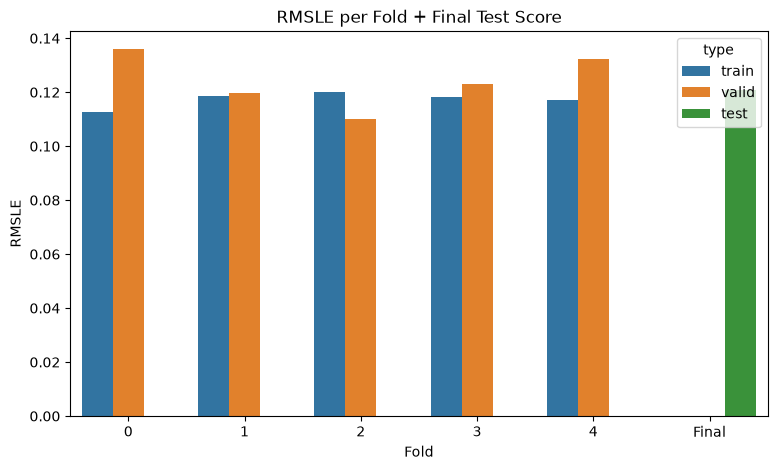

In [11]:
N_SELECT_FEATS = 30

base_model = Pipeline([
    ("prep", preprocessor),
    ("select", SelectFromModel(Ridge(alpha=1.0), max_features=N_SELECT_FEATS, threshold=-np.inf)),
    ("ridge", Ridge(alpha=1.0))
])
model = TransformedTargetRegressor(
    regressor=base_model,
    transformer=log_standardize_y,
    check_inverse=False
)

folds = 5
cv = KFold(n_splits=folds, shuffle=True, random_state=42)
result = cross_validate(
    model, X_train, y_train,
    cv=cv,
    scoring="neg_root_mean_squared_log_error",
    return_train_score=True,
)

# スコア表示
train_scores = -result["train_score"]
valid_scores = -result["test_score"]

for i, (tr, va) in enumerate(zip(train_scores, valid_scores), 1):
    print(f"Fold {i}: train RMSLE = {tr:.4f} / valid RMSLE = {va:.4f}")
print(f"CV平均: train {train_scores.mean():.4f} / valid {valid_scores.mean():.4f}")

model.fit(X_train, y_train)
test_score = root_mean_squared_log_error(y_va, model.predict(X_va))
print(f"最終スコア(test RMSLE): {test_score:.4f}")

# スコアグラフ
df = pl.DataFrame({
    "Fold": [str(i) for i in range(folds)] * 2 + ["Final"],
    "RMSLE": list(train_scores) + list(valid_scores) + [test_score],
    "type": ["train"] * folds + ["valid"] * folds + ["test"],
})

plt.figure(figsize=(9, 5))
sns.barplot(data=df, x="Fold", y="RMSLE", hue="type")

plt.title("RMSLE per Fold + Final Test Score")
plt.show()

### grid search

In [ ]:
alpha_candidates = [0.1, 1.0, 10.0, 100.0, 300.0, 1000.0]

# selectステップ(特徴量選択用Ridge)とridgeステップ(最終回帰用Ridge)のalphaを連動させて探索
param_grid = [
    {
        "regressor__select__estimator__alpha": [alpha],
        "regressor__ridge__alpha": [alpha],
    }
    for alpha in alpha_candidates
]

grid_search = GridSearchCV(
    estimator=model,
    param_grid=param_grid,
    scoring="neg_root_mean_squared_log_error",
    cv=cv,
    n_jobs=-1,
    refit=True,
)
grid_search.fit(X_train, y_train)

print(f"Best params: {grid_search.best_params_}")
print(f"Best CV RMSLE: {-grid_search.best_score_:.4f}")

best_model = grid_search.best_estimator_
test_score_gs = root_mean_squared_log_error(y_va, best_model.predict(X_va))
print(f"最終スコア(test RMSLE): {test_score_gs:.4f}")

# alphaごとのCVスコア一覧
cv_results = pd.DataFrame(grid_search.cv_results_)[
    ["param_regressor__ridge__alpha", "mean_test_score", "std_test_score"]
].assign(
    mean_test_RMSLE=lambda df: -df["mean_test_score"]
).sort_values("param_regressor__ridge__alpha")
cv_results


Best params: {'regressor__ridge__alpha': 10.0}
Best CV RMSLE: 0.1241
最終スコア(test RMSLE): 0.1207


,param_regressor__ridge__alpha,mean_test_score,std_test_score,mean_test_RMSLE
0,0.1,-0.124252,0.009550,0.124252
1,1.0,-0.124292,0.009195,0.124292
2,10.0,-0.124087,0.009075,0.124087
3,100.0,-0.126907,0.009049,0.126907
4,300.0,-0.130981,0.009099,0.130981
5,1000.0,-0.146937,0.011584,0.146937


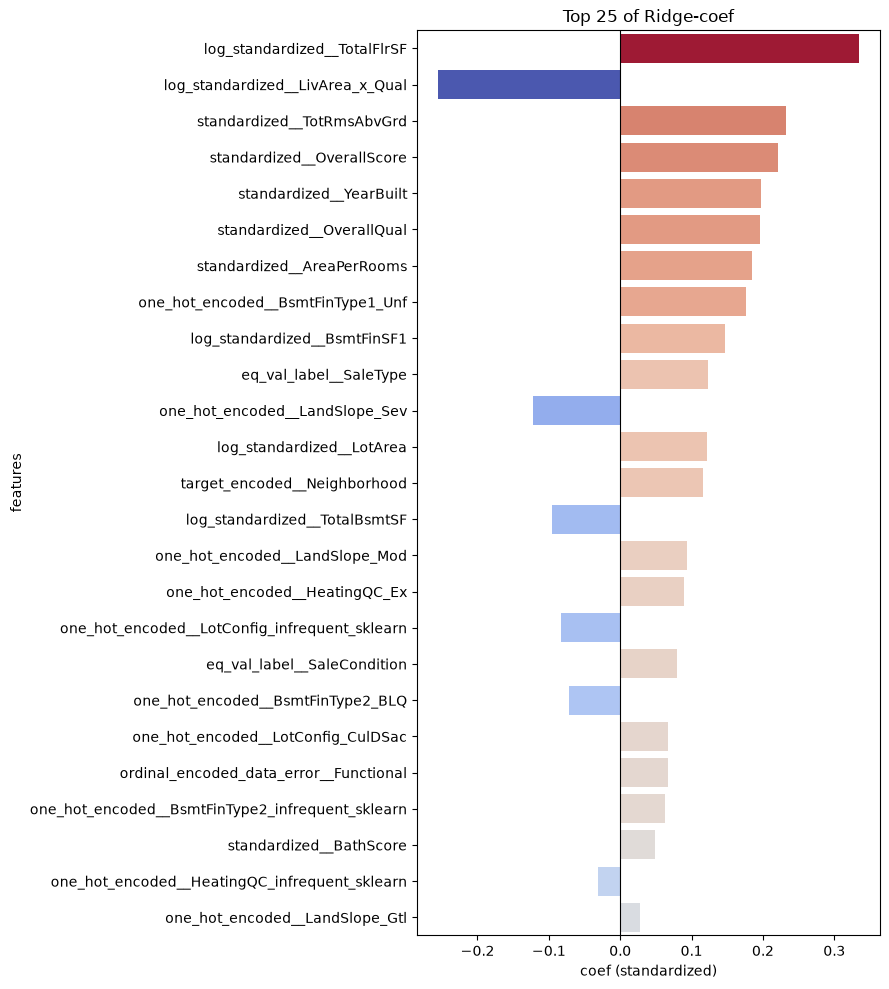

In [13]:
# 特徴量の寄与度（Ridge係数）トップ25（selectステップで選択された特徴量のみ）
all_feature_names = model.regressor_.named_steps["prep"].get_feature_names_out()
selected_mask = model.regressor_.named_steps["select"].get_support()
feature_names = all_feature_names[selected_mask]
coefs = model.regressor_.named_steps["ridge"].coef_

importance_df = pl.DataFrame({
    "feature": feature_names,
    "coef": coefs,
}).with_columns(
    pl.col("coef").abs().alias("abs_coef")
).sort("abs_coef", descending=True)

importance_df.write_csv('../data/coef.csv')

importance_df = importance_df.head(25)

plt.figure(figsize=(9, 10))
sns.barplot(
    data=importance_df.to_pandas(),
    x="coef", y="feature",
    hue="coef", palette="coolwarm", dodge=False, legend=False,
)
plt.axvline(0, color="black", linewidth=0.8)
plt.title("Top 25 of Ridge-coef")
plt.xlabel("coef (standardized)")
plt.ylabel("features")
plt.tight_layout()

plt.show()

### LightGBM

In [14]:
base_model_lgbm = Pipeline([
    ("prep", preprocessor),
    ("lgbm", LGBMRegressor(n_estimators=500, random_state=42, n_jobs=-1, verbose=-1))
])
model_lgbm = TransformedTargetRegressor(
    regressor=base_model_lgbm,
    transformer=log_standardize_y,
    check_inverse=False
)

result_lgbm = cross_validate(
    model_lgbm, X_train, y_train,
    cv=cv,
    scoring="neg_root_mean_squared_log_error",
    return_train_score=True,
)

# スコア表示
train_scores_lgbm = -result_lgbm["train_score"]
valid_scores_lgbm = -result_lgbm["test_score"]

for i, (tr, va) in enumerate(zip(train_scores_lgbm, valid_scores_lgbm), 1):
    print(f"Fold {i}: train RMSLE = {tr:.4f} / valid RMSLE = {va:.4f}")
print(f"CV平均: train {train_scores_lgbm.mean():.4f} / valid {valid_scores_lgbm.mean():.4f}")

model_lgbm.fit(X_train, y_train)
test_score_lgbm = root_mean_squared_log_error(y_va, model_lgbm.predict(X_va))
print(f"最終スコア(test RMSLE): {test_score_lgbm:.4f}")


c:\Users\tak\Documents\Projects\Kaggle\house-prices\.venv\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
c:\Users\tak\Documents\Projects\Kaggle\house-prices\.venv\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
c:\Users\tak\Documents\Projects\Kaggle\house-prices\.venv\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
c:\Users\tak\Documents\Projects\Kaggle\house-prices\.venv\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
c:\Users\tak\Documents\Projects\Kaggle\house-prices\.venv\Lib\site-packages\sklearn\utils\validation

Fold 1: train RMSLE = 0.0161 / valid RMSLE = 0.1393
Fold 2: train RMSLE = 0.0164 / valid RMSLE = 0.1263
Fold 3: train RMSLE = 0.0173 / valid RMSLE = 0.1173
Fold 4: train RMSLE = 0.0142 / valid RMSLE = 0.1208
Fold 5: train RMSLE = 0.0160 / valid RMSLE = 0.1225
CV平均: train 0.0160 / valid 0.1252
最終スコア(test RMSLE): 0.1286


c:\Users\tak\Documents\Projects\Kaggle\house-prices\.venv\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


### grid search (LightGBM)

In [15]:
param_grid_lgbm = {
    "regressor__lgbm__n_estimators": [500],
    "regressor__lgbm__num_leaves": [15, 31],
    "regressor__lgbm__learning_rate": [0.05, 0.1],
}

grid_search_lgbm = GridSearchCV(
    estimator=model_lgbm,
    param_grid=param_grid_lgbm,
    scoring="neg_root_mean_squared_log_error",
    cv=cv,
    n_jobs=-1,
    refit=True,
)
grid_search_lgbm.fit(X_train, y_train)

print(f"Best params: {grid_search_lgbm.best_params_}")
print(f"Best CV RMSLE: {-grid_search_lgbm.best_score_:.4f}")

best_model_lgbm = grid_search_lgbm.best_estimator_
test_score_gs_lgbm = root_mean_squared_log_error(y_va, best_model_lgbm.predict(X_va))
print(f"最終スコア(test RMSLE): {test_score_gs_lgbm:.4f}")

# パラメータごとのCVスコア一覧
cv_results_lgbm = pd.DataFrame(grid_search_lgbm.cv_results_)[
    ["param_regressor__lgbm__num_leaves", "param_regressor__lgbm__learning_rate", "mean_test_score", "std_test_score"]
].assign(
    mean_test_RMSLE=lambda df: -df["mean_test_score"]
).sort_values("mean_test_RMSLE")
cv_results_lgbm


Best params: {'regressor__lgbm__learning_rate': 0.05, 'regressor__lgbm__n_estimators': 500, 'regressor__lgbm__num_leaves': 15}
Best CV RMSLE: 0.1224
最終スコア(test RMSLE): 0.1273


c:\Users\tak\Documents\Projects\Kaggle\house-prices\.venv\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


,param_regressor__lgbm__num_leaves,param_regressor__lgbm__learning_rate,mean_test_score,std_test_score,mean_test_RMSLE
0,15,0.05,-0.122377,0.010317,0.122377
2,15,0.10,-0.123002,0.009425,0.123002
1,31,0.05,-0.125377,0.008194,0.125377
3,31,0.10,-0.126114,0.009680,0.126114


### submit

In [16]:
from sklearn.base import clone

# ベストハイパーパラメータで全学習データ(X, y)を使って最終学習
final_model = clone(model)
final_model.set_params(**grid_search.best_params_)
final_model.fit(X, y)

final_model_lgbm = clone(model_lgbm)
final_model_lgbm.set_params(**grid_search_lgbm.best_params_)
final_model_lgbm.fit(X, y)

# test RMSLEの逆数の比を重みとした加重平均（誤差が小さいモデルほど重みが大きくなる）
weight_en = 1 / test_score_gs
weight_lgbm = 1 / test_score_gs_lgbm
weight_sum = weight_en + weight_lgbm
weight_en /= weight_sum
weight_lgbm /= weight_sum
print(f"Ridge RMSLE: {test_score_gs:.4f} / weight: {weight_en:.4f}")
print(f"LightGBM RMSLE: {test_score_gs_lgbm:.4f} / weight: {weight_lgbm:.4f}")

pred_en = final_model.predict(X_test)
pred_lgbm = final_model_lgbm.predict(X_test)
pred_final = weight_en * pred_en + weight_lgbm * pred_lgbm

submit_df = pl.DataFrame({
    "Id": test['Id'],
    "SalePrice": pred_final
})


Ridge RMSLE: 0.1207 / weight: 0.5134
LightGBM RMSLE: 0.1273 / weight: 0.4866


c:\Users\tak\Documents\Projects\Kaggle\house-prices\.venv\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


In [17]:
submit_df.write_csv("../submit.csv")